# SSH 사슬의 밴드갭 — Tight-Binding 계산

전산물리학 중간 프로젝트 · 신효산

## 물리 질문 (하나)
> SSH 사슬에서 $t_2/t_1$에 따라 밴드갭은 어떻게 변하고, 끝이 있는 유한 사슬의 수치 계산은 그 값에 얼마나 잘 수렴하는가?

## 계산할 양
- 밴드 $E_\pm(k)$와 갭 $E_{gap}$
- 유한 사슬에서 가장 낮은 벌크 상태의 $\lvert E\rvert$ (갭으로의 수렴)
- (예비 관찰) 유한 사슬의 갭 안 상태의 개수와 위치

## 모델, 가정, 경계조건
| 항목 | 내용 |
|---|---|
| 모델 | SSH 사슬: 단위셀에 A, B 두 원자, 셀 안 hopping $t_1$, 셀 사이 hopping $t_2$ |
| 가정 | 최근접 hopping만, 오비탈은 직교, 온사이트 에너지 없음, $a=1$, $\hbar=1$ |
| 경계조건 | **주기**: 밴드, Bloch 해밀토니안, 원자 고리 / **열린**: 유한 사슬 |
| 규약 | 유한 사슬은 A 원자에서 시작하고 첫 결합이 $t_1$ |

## 수치 방법과 선택 이유
| 방법 | 이유 |
|---|---|
| 행렬 대각화 (`numpy.linalg.eigh`) | 행렬이 작아서(2×2, $2N\times2N$) **정확**하고, 시간 간격 같은 수렴 변수가 없다 |

## 입력과 출력
- 입력: `input/params.json` (없으면 기본값으로 만든다)
- 출력: `output/*.csv`, `output/summary.json`, `output/figs/*.png`

## 구성
0~6절 전부가 중간 발표 범위다. 각 절은 **예측 → 실행 → 확인** 순서다.

## 0. 설정: 입력 파일 읽기와 출력 준비

In [1]:
import csv, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

DEFAULT_PARAMS = {
    "t_monatomic": 1.0,
    "ring_N": 20,
    "ssh_pairs": [[1.0, 0.5], [0.5, 1.0]],
    "gap_table_pairs": [[1.0, 1.0], [1.0, 0.5], [0.5, 1.0], [1.0, 0.9]],
    "gap_scan": {"t1": 1.0, "t2_min": 0.0, "t2_max": 2.0, "n": 81},
    "chain": {"n_cells": 20, "edge_threshold": 0.1},
    "resolution": {
        "nk_list": [3, 4, 5, 6, 7, 8, 16, 17, 32, 33, 64],
        "nk_pairs": [[1.0, 0.5], [0.5, 1.0], [1.0, 0.95], [1.0, 1.05]],
        "ring_N_list": [10, 11, 20, 21, 40, 41, 100, 101],
        "chain_gap_ncell_list": [10, 20, 40, 80, 160],
        "chain_gap_pairs": [[1.0, 0.5], [0.5, 1.0]]
    }
}

import re
def compact_json(obj):
    # 숫자 리스트를 한 줄로 접어서 입력 파일을 읽기 쉽게 쓴다
    text = json.dumps(obj, indent=2)
    pat = re.compile(r"\[\s*([^\[\]{}]*?)\s*\]")
    prev = None
    while prev != text:
        prev = text
        text = pat.sub(lambda m: "[" + re.sub(r"\s+", " ", m.group(1)) + "]", text)
    return text

PARAMS_PATH = Path("input/params.json")
if not PARAMS_PATH.exists():
    PARAMS_PATH.parent.mkdir(parents=True, exist_ok=True)
    PARAMS_PATH.write_text(compact_json(DEFAULT_PARAMS))
    print("input/params.json 이 없어서 기본값으로 만들었다.")
P = json.loads(PARAMS_PATH.read_text())
print("입력 파일:", PARAMS_PATH.resolve())

OUT = Path("output"); FIGS = OUT / "figs"; FIGS.mkdir(parents=True, exist_ok=True)
SUMMARY = {}                                     # 핵심 수치 모음 -> output/summary.json

def save_csv(name, header, rows):
    with open(OUT / name, "w", newline="") as f:
        w = csv.writer(f); w.writerow(header); w.writerows(rows)

def save_fig(name):
    plt.savefig(FIGS / f"{name}.png", dpi=150, bbox_inches="tight")

A_LATTICE = 1.0
plt.rcParams["figure.dpi"] = 110

input/params.json 이 없어서 기본값으로 만들었다.
입력 파일: /home/claude/nb5/run/input/params.json


## 1. 베이스라인: 1D 단원자 사슬

원자가 한 종류인 사슬. Bloch 안자 $|k\rangle=\sum_n e^{ikna}|n\rangle$를 해밀토니안에 넣으면

$$E(k)=\epsilon_0-2t\cos(ka)$$

**예측**: $k=0$과 $k=\pi/a$에서 $E$는 각각 얼마인가? 밴드 폭은?

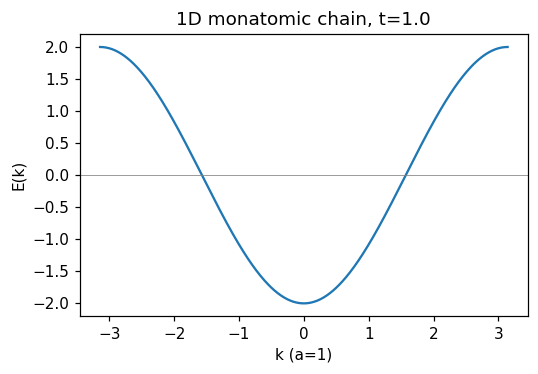

E(k=0)  = -2.0
E(k=pi) = 2.0
밴드 폭  = 4.0 (= 4t)


In [2]:
t_m = P["t_monatomic"]

def monatomic_energy(k, t=1.0, eps0=0.0, a=A_LATTICE):
    return eps0 - 2 * t * np.cos(k * a)

k_vals = np.linspace(-np.pi, np.pi, 400)
E = monatomic_energy(k_vals, t_m)

plt.figure(figsize=(5, 3.5))
plt.plot(k_vals, E)
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("k (a=1)"); plt.ylabel("E(k)")
plt.title(f"1D monatomic chain, t={t_m}")
plt.tight_layout(); save_fig("fig1_monatomic"); plt.show()
save_csv("monatomic_band.csv", ["k", "E"], zip(k_vals.tolist(), E.tolist()))

print("E(k=0)  =", monatomic_energy(0.0, t_m))
print("E(k=pi) =", monatomic_energy(np.pi, t_m))
print("밴드 폭  =", monatomic_energy(np.pi, t_m) - monatomic_energy(0.0, t_m), "(= 4t)")

**확인**: 밴드 바닥 $-2t$, 꼭대기 $+2t$, 폭 $4t$.
원자당 전자 1개면 밴드가 정확히 반만 차므로 이 사슬은 **금속**이다.

### 1-2. 행렬 대각화로 직접 확인 (주기경계조건)

해석식이 맞는지, **실공간 $N\times N$ 해밀토니안**을 직접 대각화해서 확인한다.
원자 $N$개를 고리로 이으면(주기경계조건) 허용되는 파수는 $k=\dfrac{2\pi m}{Na},\ m=0,\dots,N-1$ 이고, 고유값이 해석식 $E(k)$와 같아야 한다.

**예측**: 수치 고유값과 해석식의 차이는 어느 정도인가?

N=20: 수치 고유값과 해석식 E(k_m)의 최대 차이 = 1.11e-15


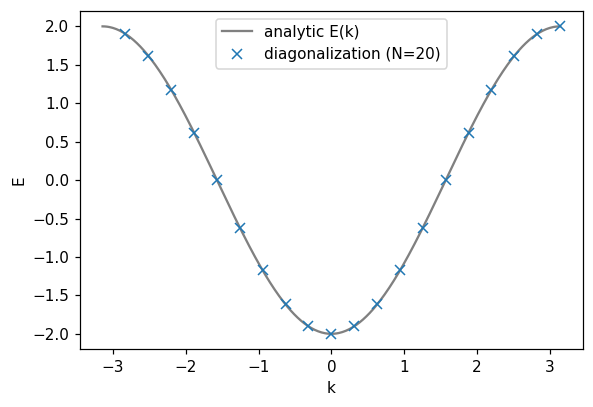

In [3]:
def ring_hamiltonian(N, t=1.0, eps0=0.0):
    H = np.eye(N) * eps0
    for n in range(N):
        H[n, (n + 1) % N] = H[(n + 1) % N, n] = -t       # 주기경계조건: 마지막 원자가 첫 원자와 연결
    return H

N = P["ring_N"]
E_num = np.sort(np.linalg.eigvalsh(ring_hamiltonian(N, t_m)))
m = np.arange(N)
k_allowed = 2 * np.pi * m / N                             # a = 1
k_allowed = np.where(k_allowed > np.pi, k_allowed - 2 * np.pi, k_allowed)   # (-pi, pi]로 접기
E_ana = monatomic_energy(k_allowed, t_m)
order = np.argsort(E_ana, kind="stable")
ring_diff = float(np.max(np.abs(E_num - E_ana[order])))
SUMMARY["ring_max_diff"] = ring_diff
print(f"N={N}: 수치 고유값과 해석식 E(k_m)의 최대 차이 = {ring_diff:.2e}")

plt.figure(figsize=(5.5, 3.8))
plt.plot(k_vals, monatomic_energy(k_vals, t_m), "-", color="gray", label="analytic E(k)")
plt.plot(k_allowed[order], E_num, "x", ms=7, label=f"diagonalization (N={N})")
plt.xlabel("k"); plt.ylabel("E"); plt.legend(); plt.tight_layout(); save_fig("fig2_ring_check"); plt.show()
save_csv("ring_check.csv", ["k", "E_numeric", "E_analytic"], zip(k_allowed[order].tolist(), E_num.tolist(), E_ana[order].tolist()))

**확인**: 수치 고유값이 해석식과 기계 정밀도(~$10^{-15}$)로 일치한다.
원자 수에 따라 달라지는 부분(짝수/홀수 $N$)은 5-2절 "수치 해상도"에서 따로 확인한다.

**질문**: 원자를 두 종류로 바꾸면 밴드는 어떻게 되는가? → 다음 절.

## 2. SSH 모델의 Bloch 해밀토니안과 밴드

단위셀에 A, B 두 원자. 셀 안 hopping $t_1$, 셀 사이 hopping $t_2$.

$$H(k)=\begin{pmatrix}0 & t_1+t_2e^{-ika}\\ t_1+t_2e^{ika} & 0\end{pmatrix},\qquad E_\pm(k)=\pm|t_1+t_2e^{ika}|$$

이 코드는 **행렬을 직접 대각화**(`eigvalsh`)해서 $E_\pm$를 얻고, 해석식과 일치하는지 `assert`로 확인한다.

**예측**: 두 사슬 $(t_1,t_2)=(1,0.5)$와 $(0.5,1)$의 밴드는 같은가, 다른가?

검증 통과 (t1=1.0, t2=0.5): 대각화와 해석식의 최대 차이 2.2e-16
검증 통과 (t1=0.5, t2=1.0): 대각화와 해석식의 최대 차이 0.0e+00


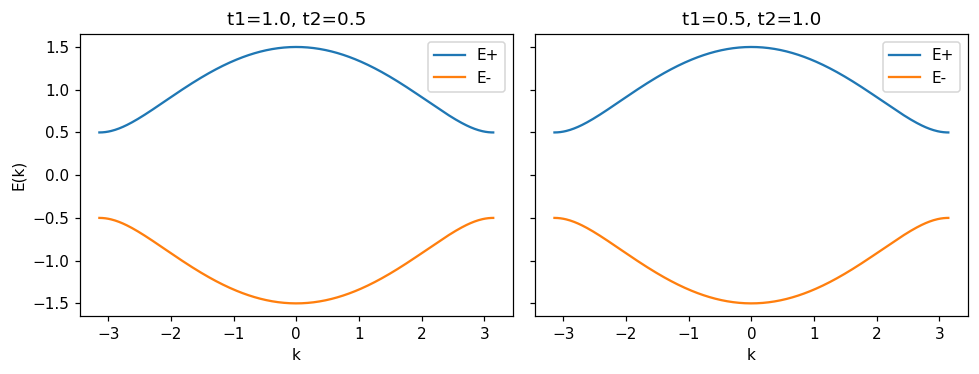

In [4]:
def ssh_hamiltonian(k, t1, t2, a=A_LATTICE):
    off = t1 + t2 * np.exp(1j * k * a)
    return np.array([[0, off], [np.conj(off), 0]], dtype=complex)

def ssh_bands(k_vals, t1, t2):
    Em, Ep = np.zeros(len(k_vals)), np.zeros(len(k_vals))
    for i, k in enumerate(k_vals):
        Em[i], Ep[i] = np.linalg.eigvalsh(ssh_hamiltonian(k, t1, t2))
    return Em, Ep

def ssh_band_diff(t1, t2, n=50):
    ks = np.linspace(-np.pi, np.pi, n)
    Em, Ep = ssh_bands(ks, t1, t2)
    analytic = np.abs(t1 + t2 * np.exp(1j * ks))
    return float(max(np.max(np.abs(Ep - analytic)), np.max(np.abs(Em + analytic))))

pairs = [tuple(p) for p in P["ssh_pairs"]]
diffs = []
for t1, t2 in pairs:
    d = ssh_band_diff(t1, t2); diffs.append(d)
    assert d < 1e-12, "대각화 결과와 해석식이 다르다"
    print(f"검증 통과 (t1={t1}, t2={t2}): 대각화와 해석식의 최대 차이 {d:.1e}")
SUMMARY["ssh_band_max_diff"] = max(diffs)

k_vals = np.linspace(-np.pi, np.pi, 400)
fig, ax = plt.subplots(1, len(pairs), figsize=(4.5 * len(pairs), 3.5), sharey=True)
cols, header = [k_vals.tolist()], ["k"]
for a_, (t1, t2) in zip(np.atleast_1d(ax), pairs):
    Em, Ep = ssh_bands(k_vals, t1, t2)
    a_.plot(k_vals, Ep, label="E+"); a_.plot(k_vals, Em, label="E-")
    a_.set_title(f"t1={t1}, t2={t2}"); a_.set_xlabel("k"); a_.legend()
    cols += [Ep.tolist(), Em.tolist()]; header += [f"E+(t1={t1},t2={t2})", f"E-(t1={t1},t2={t2})"]
np.atleast_1d(ax)[0].set_ylabel("E(k)")
plt.tight_layout(); save_fig("fig3_bands_compare"); plt.show()
save_csv("bands_ssh.csv", header, zip(*cols))

**확인**: 두 그림의 밴드 모양이 **똑같다**. $t_1\leftrightarrow t_2$를 바꿔도 $|t_1+t_2e^{ika}|$의 최솟값·최댓값이 같기 때문이다.
$k=0$에서 $|E|=t_1+t_2$, $k=\pi/a$에서 $|E|=|t_1-t_2|$.

**질문**: 밴드만 보면 두 사슬을 구별할 수 없다. 그럼 두 사슬은 정말 같은 상태인가? (→ 4절: 끝이 있는 사슬)

## 3. 밴드갭

$$E_{gap}=2|t_1-t_2|$$

**예측**: $t_1=t_2$일 때 갭은?

t1=1.0, t2=1.0 | 공식 0.000 | 수치 0.000
t1=1.0, t2=0.5 | 공식 1.000 | 수치 1.000
t1=0.5, t2=1.0 | 공식 1.000 | 수치 1.000
t1=1.0, t2=0.9 | 공식 0.200 | 수치 0.200


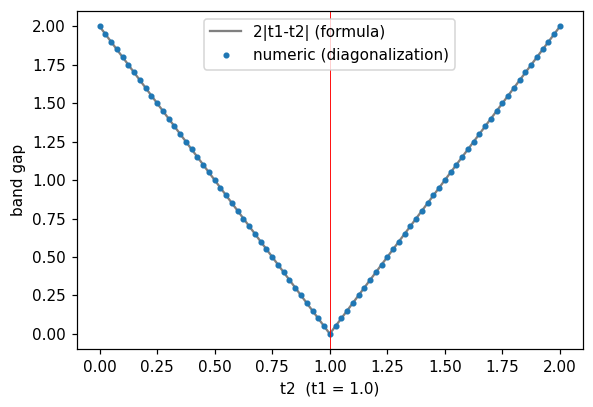

공식과 수치의 최대 차이: 2.4492935982947064e-16
t2 = t1 에서의 갭: 2.4492935982947064e-16


In [5]:
def band_gap(t1, t2):
    return 2 * abs(t1 - t2)

def gap_numeric(t1, t2, n_k=2001):
    # 각 k에서 2x2 행렬을 대각화해 갭을 직접 잰다 (grid 가 k=±pi 를 포함: linspace 양 끝점)
    ks = np.linspace(-np.pi, np.pi, n_k)
    off = t1 + t2 * np.exp(1j * ks)
    H = np.zeros((n_k, 2, 2), dtype=complex); H[:, 0, 1] = off; H[:, 1, 0] = np.conj(off)
    w = np.linalg.eigvalsh(H)
    return w[:, 1].min() - w[:, 0].max()

for t1, t2 in P["gap_table_pairs"]:
    print(f"t1={t1:.1f}, t2={t2:.1f} | 공식 {band_gap(t1,t2):.3f} | 수치 {gap_numeric(t1, t2):.3f}")

g = P["gap_scan"]
t2_grid = np.linspace(g["t2_min"], g["t2_max"], g["n"])
g_num = np.array([gap_numeric(g["t1"], t2) for t2 in t2_grid])
g_ana = 2 * np.abs(g["t1"] - t2_grid)
gap_diff = float(np.max(np.abs(g_num - g_ana)))
SUMMARY["gap_max_diff"] = gap_diff

plt.figure(figsize=(5.5, 3.8))
plt.plot(t2_grid, g_ana, "-", color="gray", label="2|t1-t2| (formula)")
plt.plot(t2_grid, g_num, ".", label="numeric (diagonalization)")
plt.axvline(g["t1"], color="r", lw=0.6)
plt.xlabel(f"t2  (t1 = {g['t1']})"); plt.ylabel("band gap"); plt.legend(); plt.tight_layout(); save_fig("fig4_gap_vs_t2"); plt.show()
save_csv("gap_vs_t2.csv", ["t2", "gap_numeric", "gap_formula"], zip(t2_grid.tolist(), g_num.tolist(), g_ana.tolist()))
print("공식과 수치의 최대 차이:", gap_diff)
print("t2 = t1 에서의 갭:", float(g_num[np.argmin(np.abs(t2_grid - g["t1"]))]))

**확인**: 갭 $=2|t_1-t_2|$이 $t_2$ 전 구간에서 수치와 일치하고, $t_2=t_1$에서 정확히 0이 된다(V자 모양).
$(1.0,0.5)$와 $(0.5,1.0)$는 **갭 크기가 똑같다**.

## 4. 예비 관찰: 유한 사슬의 갭 안 상태

Bloch 정리는 무한 주기계에만 적용되므로, 끝이 있는 사슬은 **실공간 행렬**을 직접 만들어 대각화한다 (열린 경계조건). 사슬은 A 원자에서 시작하고 셀 안 결합을 $t_1$로 둔다.

**예측**: 두 사슬 $(t_1,t_2)=(1,0.5)$와 $(0.5,1)$의 스펙트럼은 어떻게 다른가?

t1 > t2: E=0 근처 상태 0개, 가장 가까운 두 에너지 = [ 0.5101 -0.5101]
t2 > t1: E=0 근처 상태 2개, 가장 가까운 두 에너지 = [-0.  0.]


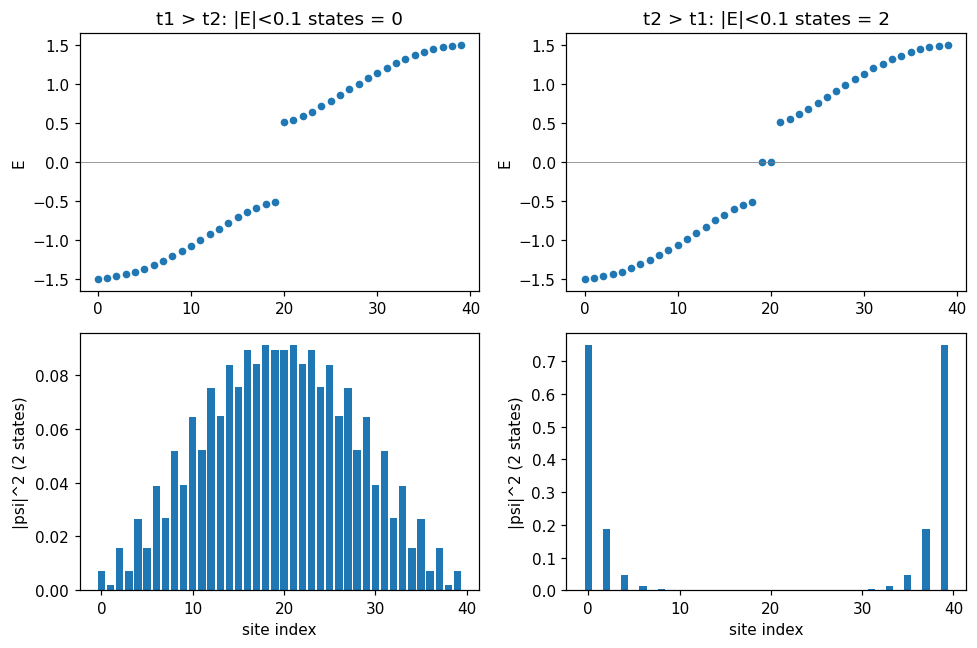

In [6]:
def finite_ssh(n_cells, t1, t2):
    n = 2 * n_cells
    H = np.zeros((n, n))
    for c in range(n_cells):
        H[2*c, 2*c+1] = H[2*c+1, 2*c] = t1          # 셀 안: A_c - B_c
    for c in range(n_cells - 1):
        H[2*c+1, 2*c+2] = H[2*c+2, 2*c+1] = t2      # 셀 간: B_c - A_{c+1}
    return H

N_CELLS = P["chain"]["n_cells"]; THR = P["chain"]["edge_threshold"]
fig, ax = plt.subplots(2, len(pairs), figsize=(4.5 * len(pairs), 6))
edge_cols, edge_head, dens_cols = [], ["index"], []
edge_counts = {}
for col, (t1, t2) in enumerate(pairs):
    name = "t2 > t1" if t2 > t1 else "t1 > t2"
    E, V = np.linalg.eigh(finite_ssh(N_CELLS, t1, t2))
    n_zero = int(np.sum(np.abs(E) < THR)); edge_counts[name] = n_zero
    ax[0, col].plot(E, "o", ms=4); ax[0, col].axhline(0, color="gray", lw=0.5)
    ax[0, col].set_title(f"{name}: |E|<{THR} states = {n_zero}"); ax[0, col].set_ylabel("E")
    idx = np.argsort(np.abs(E))[:2]                  # E=0에 가장 가까운 상태 2개
    dens = np.sum(np.abs(V[:, idx])**2, axis=1)
    ax[1, col].bar(range(len(dens)), dens)
    ax[1, col].set_xlabel("site index"); ax[1, col].set_ylabel("|psi|^2 (2 states)")
    print(f"{name}: E=0 근처 상태 {n_zero}개, 가장 가까운 두 에너지 = {np.round(E[idx], 5)}")
    edge_cols.append(E.tolist()); edge_head.append(f"E(t1={t1},t2={t2})"); dens_cols.append(dens.tolist())
plt.tight_layout(); save_fig("fig6_edge_states"); plt.show()
save_csv("edge_states.csv", edge_head, [[i] + [c[i] for c in edge_cols] for i in range(2 * N_CELLS)])
save_csv("edge_density.csv", ["site"] + [f"density(t1={a},t2={b})" for a, b in pairs], [[i] + [c[i] for c in dens_cols] for i in range(2 * N_CELLS)])
SUMMARY["edge_state_count"] = edge_counts

**확인 (관찰)**
- $t_1>t_2$: $\lvert E\rvert<0.1$ 상태 **0개**, 가장 가까운 에너지 $\pm0.51$
- $t_2>t_1$: 갭 안 $E\approx0$ 상태 **2개**, 확률이 사슬 **양 끝**에 몰려 있다

이것은 **관찰**이다. 왜 이 상태가 생기고 유지되는지는 기말에서 다룬다. $t_1=0$ 극한의 직관은 5-1절에 있다.

## 5. 검증

네 가지 관점으로 점검한다: **5-1 기준과의 비교, 5-2 수치 해상도, 5-3 샘플링**, 그리고 6절의 해석과 한계.

### 5-1. 기준(reference)과의 비교: 정확한 결과와 극한 경우

**예측**: $t_1=0$ 극한에서는 끝 원자가 이웃과 완전히 끊어진다. 이때 영모드는 어떤 모양이어야 하는가? $t_2=0$ 극한에서는?

In [7]:
# (a) t1 -> 0 : 끝 원자 A_1 과 B_N 이 완전히 분리 -> 정확한 영모드 2개, 확률은 끝 사이트에 100 %
E0, V0 = np.linalg.eigh(finite_ssh(N_CELLS, 0.0, 1.0))
zero_idx = np.where(np.abs(E0) < 1e-12)[0]
dens0 = np.sum(np.abs(V0[:, zero_idx])**2, axis=1)
print(f"t1=0, t2=1: |E|<1e-12 상태 {len(zero_idx)}개, 끝 사이트 확률 = {dens0[0]:.6f}, {dens0[-1]:.6f}")
print(f"           나머지 |E| 의 최솟값/최댓값 = {np.min(np.abs(E0[np.abs(E0) > 1e-12])):.4f} / {np.max(np.abs(E0)):.4f}  (이론: 모두 t2 = 1)")

# (b) t2 -> 0 : 이합체(dimer)만 남음 -> 모든 |E| = t1, 영모드 없음
E1 = np.linalg.eigvalsh(finite_ssh(N_CELLS, 1.0, 0.0))
print(f"t1=1, t2=0: |E| 범위 = {np.min(np.abs(E1)):.4f} ~ {np.max(np.abs(E1)):.4f}  (이론: 모두 t1 = 1), |E|<0.1 상태 {int(np.sum(np.abs(E1) < 0.1))}개")

SUMMARY["limit_t1_0"] = {"zero_modes": int(len(zero_idx)), "end_site_prob": [float(dens0[0]), float(dens0[-1])]}
SUMMARY["limit_t2_0"] = {"abs_E_min": float(np.min(np.abs(E1))), "abs_E_max": float(np.max(np.abs(E1)))}

# (c) t1 = t2 : 단원자 고리로 돌아가는가 (3절의 수치를 요약)
def ssh_ring(n_cells, t1, t2):
    Nn = 2 * n_cells; H = np.zeros((Nn, Nn))
    for q in range(Nn):
        t = t1 if q % 2 == 0 else t2                      # 결합이 t1, t2 번갈아
        H[q, (q + 1) % Nn] = H[(q + 1) % Nn, q] = t
    return H
E_ssh_eq = np.sort(np.linalg.eigvalsh(ssh_ring(20, 1.0, 1.0)))
E_chain = np.sort(np.linalg.eigvalsh(-ring_hamiltonian(40, 1.0)))
eq_diff = float(np.max(np.abs(E_ssh_eq - E_chain)))
SUMMARY["t1_eq_t2_ring_diff"] = eq_diff
print(f"t1=t2 인 SSH 고리 vs 원자 40개 단원자 고리: 스펙트럼 최대 차이 = {eq_diff:.1e}")
print("t1=1, t2=0.5 고리에서 |E|의 최솟값:", float(np.min(np.abs(np.linalg.eigvalsh(ssh_ring(20, 1.0, 0.5))))), "(이론: |t1-t2| = 0.5)")

print()
print("기준과의 비교 요약")
print(f"  단원자 고리 vs 해석식              : {SUMMARY['ring_max_diff']:.1e}")
print(f"  SSH 밴드 vs 해석식                  : {SUMMARY['ssh_band_max_diff']:.1e}")
print(f"  갭 vs 2|t1-t2|                      : {SUMMARY['gap_max_diff']:.1e}")
print(f"  t1=t2 극한 (단원자 고리와 비교)     : {eq_diff:.1e}")
print(f"  t1=0 극한 (영모드 2개, 끝 사이트 1) : {len(zero_idx)}개, {dens0[0]:.3f}/{dens0[-1]:.3f}")

t1=0, t2=1: |E|<1e-12 상태 2개, 끝 사이트 확률 = 1.000000, 1.000000
           나머지 |E| 의 최솟값/최댓값 = 1.0000 / 1.0000  (이론: 모두 t2 = 1)
t1=1, t2=0: |E| 범위 = 1.0000 ~ 1.0000  (이론: 모두 t1 = 1), |E|<0.1 상태 0개
t1=t2 인 SSH 고리 vs 원자 40개 단원자 고리: 스펙트럼 최대 차이 = 0.0e+00
t1=1, t2=0.5 고리에서 |E|의 최솟값: 0.49999999999999967 (이론: |t1-t2| = 0.5)

기준과의 비교 요약
  단원자 고리 vs 해석식              : 1.1e-15
  SSH 밴드 vs 해석식                  : 2.2e-16
  갭 vs 2|t1-t2|                      : 2.4e-16
  t1=t2 극한 (단원자 고리와 비교)     : 0.0e+00
  t1=0 극한 (영모드 2개, 끝 사이트 1) : 2개, 1.000/1.000


**확인**: 정확한 해석식, 그리고 해가 알려진 극한($t_1=t_2$, $t_1\to0$, $t_2\to0$) 모두에서 수치 결과가 일치한다.
특히 $t_1=0$에서는 끝 원자가 완전히 끊어져 **정확한** 영모드 2개가 끝 사이트에 100 % 몰려 있다 — 에지 상태가 $t_1\neq0$에서도 이 극한에서 연속적으로 이어진 상태라는 직관을 준다.

### 5-2. 수치 해상도: $k$ 격자, 원자 수, 사슬 길이

| 바꾸는 것 | 보는 양 | 이론적 기대 |
|---|---|---|
| $k$ 격자 점 수 $N_k$ ($\Gamma$ 중심: $k_j=2\pi j/N_k$) | 갭의 수치 오차 | 짝수 $N_k$는 갭이 가장 작은 $k=\pi$를 지나므로 정확, 홀수는 건너뜀 |
| 고리의 원자 수 $N$ | 밴드 꼭대기와 $2t$의 차이 | 홀수 $N$: $2t(1-\cos(\pi/N))$ |
| 유한 사슬의 셀 수 $N_c$ | 가장 낮은 벌크 상태 $\lvert E\rvert$ 와 $\lvert t_1-t_2\rvert$ 의 차이 | $\propto1/N_c^2$ |

**예측**: 사슬이 길어질수록 열린 사슬의 갭은 이론값에 얼마나 빨리 수렴하는가?

In [8]:
R = P["resolution"]

# (a) k 격자 (Gamma-centered: k_j = 2 pi j / N_k, (-pi, pi]로 접음)
def gamma_grid(nk):
    k = 2 * np.pi * np.arange(nk) / nk
    return np.where(k > np.pi, k - 2 * np.pi, k)

def gap_on_grid(t1, t2, k):
    off = t1 + t2 * np.exp(1j * k)
    H = np.zeros((len(k), 2, 2), dtype=complex); H[:, 0, 1] = off; H[:, 1, 0] = np.conj(off)
    w = np.linalg.eigvalsh(H)
    return w[:, 1].min() - w[:, 0].max()

print("[k 격자]  pair = (t1, t2): N_k 에 따른 갭 오차")
kgrid_rows = []
for (t1, t2) in R["nk_pairs"]:
    print(f"  (t1,t2)=({t1},{t2}), 정확한 갭 = {band_gap(t1,t2):.3f}")
    for nk in R["nk_list"]:
        err = gap_on_grid(t1, t2, gamma_grid(nk)) - band_gap(t1, t2)
        kgrid_rows.append([t1, t2, nk, err]); print(f"     N_k={nk:3d}: 갭 오차 {err:+.2e}")
save_csv("resolution_kgrid_gap.csv", ["t1", "t2", "N_k", "gap_error"], kgrid_rows)

[k 격자]  pair = (t1, t2): N_k 에 따른 갭 오차
  (t1,t2)=(1.0,0.5), 정확한 갭 = 1.000
     N_k=  3: 갭 오차 +7.32e-01
     N_k=  4: 갭 오차 +0.00e+00
     N_k=  5: 갭 오차 +3.28e-01
     N_k=  6: 갭 오차 +0.00e+00
     N_k=  7: 갭 오차 +1.82e-01
     N_k=  8: 갭 오차 +0.00e+00
     N_k= 16: 갭 오차 +0.00e+00
     N_k= 17: 갭 오차 +3.35e-02
     N_k= 32: 갭 오차 +0.00e+00
     N_k= 33: 갭 오차 +9.02e-03
     N_k= 64: 갭 오차 +0.00e+00
  (t1,t2)=(0.5,1.0), 정확한 갭 = 1.000
     N_k=  3: 갭 오차 +7.32e-01
     N_k=  4: 갭 오차 +0.00e+00
     N_k=  5: 갭 오차 +3.28e-01
     N_k=  6: 갭 오차 +0.00e+00
     N_k=  7: 갭 오차 +1.82e-01
     N_k=  8: 갭 오차 +0.00e+00
     N_k= 16: 갭 오차 +0.00e+00
     N_k= 17: 갭 오차 +3.35e-02
     N_k= 32: 갭 오차 +0.00e+00
     N_k= 33: 갭 오차 +9.02e-03
     N_k= 64: 갭 오차 +0.00e+00
  (t1,t2)=(1.0,0.95), 정확한 갭 = 0.100
     N_k=  3: 갭 오차 +1.85e+00
     N_k=  4: 갭 오차 +0.00e+00
     N_k=  5: 갭 오차 +1.11e+00
     N_k=  6: 갭 오차 +0.00e+00
     N_k=  7: 갭 오차 +7.73e-01
     N_k=  8: 갭 오차 +0.00e+00
     N_k= 16: 갭 오차 +0.00e+00
     N_k= 17: 


[고리 원자 수]  N : 2t - E_max | 이론(홀수) 2t(1-cos(pi/N))
  N=  10: -4.441e-16 | 0.000e+00
  N=  11: 8.101e-02 | 8.101e-02
  N=  20: 0.000e+00 | 0.000e+00
  N=  21: 2.234e-02 | 2.234e-02
  N=  40: -4.441e-16 | 0.000e+00
  N=  41: 5.868e-03 | 5.868e-03
  N= 100: -4.441e-16 | 0.000e+00
  N= 101: 9.674e-04 | 9.674e-04

[유한 사슬 길이]  N_c : (가장 낮은 벌크 |E|) - |t1-t2|
  (t1,t2)=(1.0,0.5): 10:3.33e-02, 20:1.01e-02, 40:2.79e-03, 80:7.33e-04, 160:1.88e-04
     log-log 기울기 -1.92 (이론 -2) | 오차*N_c^2 (N_c=160) = 4.81 (이론 극한 4.93)
  (t1,t2)=(0.5,1.0): 10:5.58e-02, 20:1.34e-02, 40:3.23e-03, 80:7.90e-04, 160:1.95e-04
     log-log 기울기 -2.03 (이론 -2) | 오차*N_c^2 (N_c=160) = 5.00 (이론 극한 4.93)


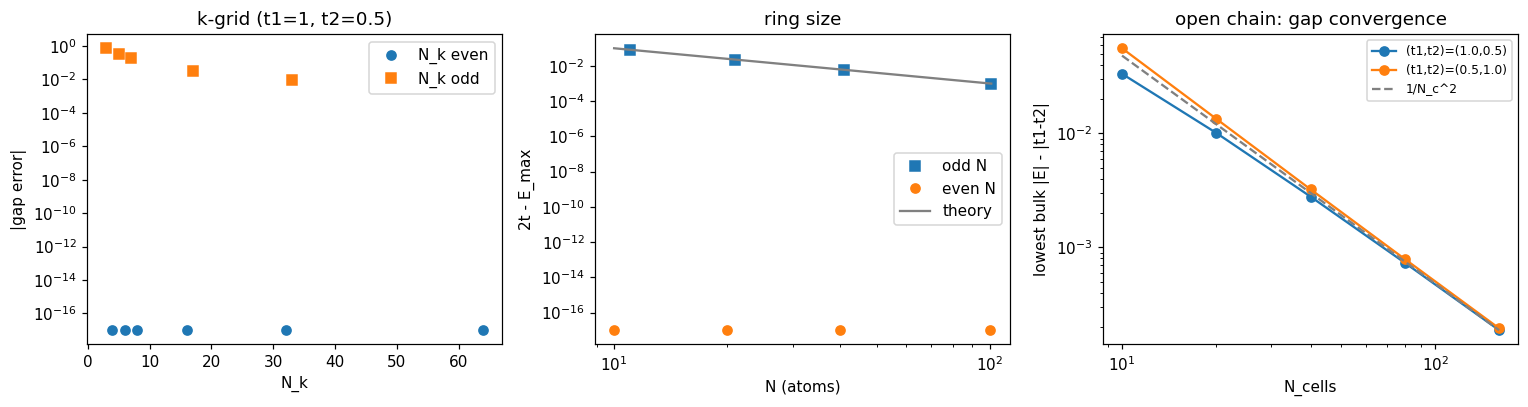

In [9]:
# (b) 고리의 원자 수: 밴드 꼭대기 2t 와의 차이
ring_rows = []
print("\n[고리 원자 수]  N : 2t - E_max | 이론(홀수) 2t(1-cos(pi/N))")
for Nn in R["ring_N_list"]:
    deficit = 2 * t_m - np.linalg.eigvalsh(ring_hamiltonian(Nn, t_m)).max()
    theory = 2 * t_m * (1 - np.cos(np.pi / Nn)) if Nn % 2 == 1 else 0.0
    ring_rows.append([Nn, deficit, theory]); print(f"  N={Nn:4d}: {deficit:.3e} | {theory:.3e}")
save_csv("resolution_ring.csv", ["N", "deficit_2t_minus_Emax", "theory_odd"], ring_rows)

# (c) 유한 사슬 길이: 열린 사슬에서 가장 낮은 벌크 상태 |E| 가 |t1 - t2| 에 수렴하는 속도
def bulk_edge_energy(nc, t1, t2):
    E = np.sort(np.abs(np.linalg.eigvalsh(finite_ssh(nc, t1, t2))))
    return E[0] if t1 > t2 else E[2]          # t2 > t1 이면 갭 안 상태 2개(E[0], E[1])를 건너뛴다

Ng = np.array(R["chain_gap_ncell_list"], float); gapconv_rows = []; gapconv = {}
print("\n[유한 사슬 길이]  N_c : (가장 낮은 벌크 |E|) - |t1-t2|")
for (t1, t2) in R["chain_gap_pairs"]:
    errs = np.array([bulk_edge_energy(int(nc), t1, t2) - abs(t1 - t2) for nc in Ng])
    gapconv[(t1, t2)] = errs
    for nc, e in zip(Ng, errs): gapconv_rows.append([t1, t2, int(nc), float(e)])
    sel = Ng >= 20
    slope = float(np.polyfit(np.log(Ng[sel]), np.log(errs[sel]), 1)[0])
    coef = t1 * t2 * np.pi**2 / (2 * abs(t1 - t2))
    print(f"  (t1,t2)=({t1},{t2}): " + ", ".join(f"{int(nc)}:{e:.2e}" for nc, e in zip(Ng, errs)))
    print(f"     log-log 기울기 {slope:.2f} (이론 -2) | 오차*N_c^2 (N_c={int(Ng[-1])}) = {errs[-1]*Ng[-1]**2:.2f} (이론 극한 {coef:.2f})")
    SUMMARY[f"chain_gap_t1={t1},t2={t2}"] = {"errors": [float(e) for e in errs], "slope": slope, "err_times_N2_last": float(errs[-1] * Ng[-1]**2), "theory_coefficient": float(coef)}
save_csv("resolution_chain_gap.csv", ["t1", "t2", "N_cells", "gap_error"], gapconv_rows)

fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
rows = [r for r in kgrid_rows if r[0] == R["nk_pairs"][0][0] and r[1] == R["nk_pairs"][0][1]]
nks = np.array([r[2] for r in rows]); errs_k = np.array([abs(r[3]) for r in rows]); ev = nks % 2 == 0
ax[0].semilogy(nks[ev], np.maximum(errs_k[ev], 1e-17), "o", label="N_k even"); ax[0].semilogy(nks[~ev], errs_k[~ev], "s", label="N_k odd")
ax[0].set_xlabel("N_k"); ax[0].set_ylabel("|gap error|"); ax[0].set_title("k-grid (t1=1, t2=0.5)"); ax[0].legend()
Ns = np.array([r[0] for r in ring_rows]); df = np.array([r[1] for r in ring_rows]); od = Ns % 2 == 1
ax[1].loglog(Ns[od], df[od], "s", label="odd N"); ax[1].loglog(Ns[~od], np.maximum(df[~od], 1e-17), "o", label="even N")
xx = np.linspace(Ns.min(), Ns.max(), 50); ax[1].loglog(xx, 2 * t_m * (1 - np.cos(np.pi / xx)), "-", color="gray", label="theory")
ax[1].set_xlabel("N (atoms)"); ax[1].set_ylabel("2t - E_max"); ax[1].set_title("ring size"); ax[1].legend()
for (t1, t2), e in gapconv.items(): ax[2].loglog(Ng, e, "o-", label=f"(t1,t2)=({t1},{t2})")
k0 = list(gapconv.values())[0]; ax[2].loglog(Ng, k0[-1] * (Ng[-1] / Ng) ** 2, "--", color="gray", label="1/N_c^2")
ax[2].set_xlabel("N_cells"); ax[2].set_ylabel("lowest bulk |E| - |t1-t2|"); ax[2].set_title("open chain: gap convergence"); ax[2].legend(fontsize=8)
plt.tight_layout(); save_fig("fig8_resolution"); plt.show()

**확인**
- **$k$ 격자**: 짝수 $N_k$는 갭 오차가 0이다. 홀수 $N_k$는 $k=\pi$를 건너뛰어 갭을 과대평가하고, 점이 늘수록 줄어든다 (예: $(1,0.5)$, $N_k=3$에서 $+0.73$, $N_k=17$에서 $+0.033$, $N_k=33$에서 $+0.009$).
- **고리 원자 수**: 짝수 $N$은 꼭대기가 $2t$ (오차 $\sim10^{-16}$), 홀수 $N$은 $2t(1-\cos(\pi/N))$만큼 모자라며 이론과 일치한다 ($N=11$: 0.081, $N=101$: $9.7\times10^{-4}$).
- **사슬 길이**: 오차가 셀 수가 두 배가 될 때 약 1/4로 줄어든다 ($\propto1/N_c^2$, 로그 기울기 $-1.9\sim-2.0$). $(t_1,t_2)=(1,0.5)$에서 오차 $\times N_c^2$ 가 $N_c=160$에서 $4.8$로 이론 극한 $\dfrac{t_1t_2\pi^2}{2\lvert t_1-t_2\rvert}=4.93$에 접근한다. 갭이 아주 작은 $(1,0.9)$는 $N_c\le160$에서 아직 점근 영역에 들어오지 못한다.

### 5-3. 샘플링: 해당 없음

이 노트북의 본문(0~5절) 계산은 모두 **난수를 쓰지 않는 결정론적 계산**이다. 따라서 표본 수에 따른 불확도는 없고, 수치 불확도는 기계 정밀도($\sim10^{-15}$)뿐이다.

In [10]:
print("샘플링: 해당 없음 (난수를 쓰지 않는 결정론적 계산). 불확도 = 기계 정밀도 ~1e-15")
SUMMARY["sampling"] = "not applicable (deterministic)"

샘플링: 해당 없음 (난수를 쓰지 않는 결정론적 계산). 불확도 = 기계 정밀도 ~1e-15


## 6. 해석과 한계

**해석**
- 갭은 $E_{gap}=2\lvert t_1-t_2\rvert$이고 $t_1=t_2$에서 닫힌다. 두 밴드가 가장 가까워지는 곳이 $k=\pi/a$다.
- $t_1=t_2$인 사슬은 균일한 단원자 사슬이다. 셀 두 개짜리로 다시 세면 밴드가 접혀 $k=\pi/a$에서 두 밴드가 만나고, $t_1\neq t_2$는 주기를 2배로 만드는 섭동이라 이 만나는 점을 밀어 갈라 갭을 연다 (이량체화, Peierls 불안정성은 이론에서 인용, 증명하지 않음).
- 채움: 단원자 사슬은 원자당 전자 1개라 반만 차서 금속, SSH는 셀당 전자 2개라 아래 밴드가 가득 차서 갭이 열려 있으면 절연체.

**확인하지 않은 것과 확인 방법**
| 확인하지 않은 것 | 어떻게 확인할 것인가 |
|---|---|
| 실제 물질(폴리아세틸렌)의 $t_1,t_2$ | 문헌의 hopping 값으로 같은 계산을 반복하고 측정된 갭과 비교 |
| 사슬 길이 $N_c\le160$ 너머, 갭이 아주 작은 경우 | 더 긴 사슬을 돌려 $1/N_c^2$ 추세 확인 |
| 갭 안 상태가 유지되는 이유 | 기말에서 진폭 해석과 무질서 비교로 다룬다 |
| 2차원(그래핀), 전자 사이의 상호작용 | 이 모델의 범위 밖 |

**규약 주의**: 유한 사슬은 A 원자에서 시작하고 셀 안 결합이 $t_1$이다. 이 규약을 바꾸면 갭 안 상태가 생기는 사슬이 뒤바뀐다.

## 출력 파일 저장

In [11]:
with open(OUT / "summary.json", "w") as f:
    json.dump(SUMMARY, f, indent=2, ensure_ascii=False, default=float)
print("저장된 출력 파일:")
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print(" ", p.as_posix(), f"({p.stat().st_size} bytes)")

저장된 출력 파일:
  output/bands_ssh.csv (38951 bytes)
  output/edge_density.csv (1899 bytes)
  output/edge_states.csv (1748 bytes)
  output/figs/fig1_monatomic.png (34663 bytes)
  output/figs/fig2_ring_check.png (40648 bytes)
  output/figs/fig3_bands_compare.png (50112 bytes)
  output/figs/fig4_gap_vs_t2.png (45810 bytes)
  output/figs/fig6_edge_states.png (50890 bytes)
  output/figs/fig8_resolution.png (102087 bytes)
  output/gap_vs_t2.csv (2997 bytes)
  output/monatomic_band.csv (15857 bytes)
  output/resolution_chain_gap.csv (362 bytes)
  output/resolution_kgrid_gap.csv (1031 bytes)
  output/resolution_ring.csv (326 bytes)
  output/ring_check.csv (1140 bytes)
  output/summary.json (1079 bytes)
